In [1]:
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 10,
})

BLUE, RED, GREY, AMBER, GREEN = '#4878CF', '#E84D0E', '#888888', '#F0A500', '#4dac26'

In [13]:
# =============================================================================
# PARAMETERS -- edit this cell to explore how results change
# =============================================================================

# --- Seeds ---
VENDOR_SEED    = 1     # integer >= 0; different seeds simulate consulting a different vendor
PORTFOLIO_SEED = 42    # keep fixed to compare vendors on the same loan book

# --- Probability framing ---
# Two framings:
#
#  CONDITIONAL -- the 1-in-200 year flood is treated as certain (p = 1).
#                 Uses the full d_200yr damage ratio.  Isolates vendor disagreement.
#
#  AAL          -- converts 200yr RP damage to expected annual damage:
#                      d_eff = d_200yr * AAL_FACTOR
#                  More natural for ongoing capital planning or provisioning.
#
# AAL_FACTOR guidance:
#   1/200 = 0.005  -- flat hazard curve / simplest assumption
#   Values above 0.005 reflect heavier-tailed exceedance curves.

FRAMING    = 'aal'  # 'conditional'  or  'aal'
AAL_FACTOR = 0.25           # scales d_200yr -> effective annual damage

# --- Damage pass-through ---
# THETA controls what fraction of physical damage reduces collateral market value.
# THETA = 1.0: full pass-through (£1 damage -> £1 collateral reduction)
# THETA < 1.0: partial (insurance, resilience, flood barriers etc.)
THETA = 1.0

# --- Basel III SA underwriting thresholds ---
LTV_BAR_1 = 0.60   # approve at standard terms if stressed LTV <= this
LTV_BAR_2 = 0.80   # conditional approval if stressed LTV <= this; reject above

# --- Risk weights by LTV band ---
RW_STANDARD    = 0.60   # LTV <= LTV_BAR_1
RW_CONDITIONAL = 0.75   # LTV_BAR_1 < LTV <= LTV_BAR_2
RW_REJECT      = 1.05   # LTV > LTV_BAR_2

CAPITAL_RATIO = 0.08    # Basel III minimum (Tier 1 + Tier 2)

# --- Loan portfolio ---
# Each loan: V0 = property value, LTV0 = origination LTV, Loan = LTV0 * V0
V0_LN_MU    = -0.2   # log-mean of property value (median ~GBP 0.8m)
V0_LN_SIGMA =  0.5   # log-std
LTV0_LOW    =  0.60  # origination LTV lower bound
LTV0_HIGH   =  0.90  # origination LTV upper bound

# --- Vendor uncertainty sweep ---
N_VENDOR_DRAWS = 100   # number of vendor draws for the uncertainty analysis

# --- Data ---
DATA_PATH = '../../data/raw/cfrf_garp_defended_flood.csv'

In [14]:
# =============================================================================
# DATA, PORTFOLIO, AND TRANSMISSION
# Run this cell after editing parameters above.
# =============================================================================

df = pd.read_csv(DATA_PATH)
df.rename(columns={'minimim_dr': 'minimum_dr'}, inplace=True)
df = df.dropna(subset=['property_rank']).reset_index(drop=True)
df['property_rank'] = df['property_rank'].astype(int)
n = len(df)

# Triangular distribution parameters for each property (mode from mean constraint)
tri_a = df['minimum_dr'].values.astype(float)
tri_b = df['maximum_dr'].values.astype(float)
tri_c = np.clip(3.0 * df['mean_dr'].values - tri_a - tri_b, tri_a, tri_b)

def triangular_sample(rng, a, b, c):
    """Draw one sample per property from Triangular(a, c, b)."""
    u    = rng.uniform(size=len(a))
    span = np.where(b > a, b - a, 1.0)
    fc   = np.where(b > a, (c - a) / span, 0.0)
    left  = a + np.sqrt(np.maximum(u,       0) * span * np.maximum(c - a, 0))
    right = b - np.sqrt(np.maximum(1 - u,   0) * span * np.maximum(b - c, 0))
    x = np.where(u <= fc, left, right)
    return np.where(b > a, np.clip(x, 0, 1), a)

# ── Sample one vendor draw ────────────────────────────────────────────────────
vendor_rng = np.random.default_rng(VENDOR_SEED)
d_vendor   = triangular_sample(vendor_rng, tri_a, tri_b, tri_c)

# ── Loan portfolio ────────────────────────────────────────────────────────────
port_rng = np.random.default_rng(PORTFOLIO_SEED)
v0 = stats.lognorm.rvs(
    s=V0_LN_SIGMA, scale=np.exp(V0_LN_MU), size=n,
    random_state=int(port_rng.integers(2**31))
)
ltv_0 = port_rng.uniform(LTV0_LOW, LTV0_HIGH, size=n)
loan  = ltv_0 * v0   # outstanding balance = LTV0 * property value

# ── Transmission functions ────────────────────────────────────────────────────
def eff_damage(d):
    """Apply framing: return effective damage ratio used in transmission."""
    return d if FRAMING == 'conditional' else d * AAL_FACTOR

def transmit(d, theta=THETA, bar1=LTV_BAR_1, bar2=LTV_BAR_2):
    """Damage ratio -> impaired collateral -> stressed LTV -> outcome bucket -> RWA."""
    d_e   = eff_damage(d)
    v_imp = np.maximum(v0 * (1.0 - theta * d_e), v0 * 1e-6)
    ltv_s = loan / v_imp
    out   = np.where(ltv_s <= bar1, 0, np.where(ltv_s <= bar2, 1, 2))
    rw    = np.array([RW_STANDARD, RW_CONDITIONAL, RW_REJECT])[out]
    rwa   = loan * rw
    cap   = CAPITAL_RATIO * rwa
    return ltv_s, out, rwa, cap

# ── Apply to single vendor draw ───────────────────────────────────────────────
ltv_stressed, outcome, rwa, capital = transmit(d_vendor)

# ── Baseline (no damage) ──────────────────────────────────────────────────────
ltv_base    = ltv_0
outcome_base = np.where(ltv_base <= LTV_BAR_1, 0,
               np.where(ltv_base <= LTV_BAR_2, 1, 2))
rw_base     = np.array([RW_STANDARD, RW_CONDITIONAL, RW_REJECT])[outcome_base]
rwa_base    = loan * rw_base
capital_base = CAPITAL_RATIO * rwa_base

# ── Point-estimate outcomes at d_min / d_mean / d_max ────────────────────────
_, out_min,  rwa_min,  _  = transmit(tri_a)
_, out_mean, rwa_mean, _  = transmit(df['mean_dr'].values)
_, out_max,  rwa_max,  _  = transmit(tri_b)

# ── Sort index by mean damage ─────────────────────────────────────────────────
idx   = np.argsort(df['mean_dr'].values)
x_pos = np.arange(n)

# ── Summary ───────────────────────────────────────────────────────────────────
framing_label = 'Conditional (p=1)' if FRAMING == 'conditional' else f'AAL (×{AAL_FACTOR})'
out_names = ['Standard', 'Conditional', 'Reject']
counts = [(outcome == k).sum() for k in range(3)]
print(f"Framing: {framing_label}  |  theta={THETA}  |  Vendor seed={VENDOR_SEED}")
print(f"\nBaseline (no damage):")
print(f"  {'  '.join(f'{out_names[k]}: {(outcome_base==k).sum():2d}' for k in range(3))}")
print(f"  Portfolio RWA: GBP{rwa_base.sum():.3f}m   Capital: GBP{capital_base.sum():.4f}m")
print(f"\nSingle vendor draw:")
print(f"  {'  '.join(f'{out_names[k]}: {counts[k]:2d}' for k in range(3))}")
print(f"  Portfolio RWA: GBP{rwa.sum():.3f}m   Capital: GBP{capital.sum():.4f}m")
print(f"  RWA uplift vs baseline: {(rwa.sum()/rwa_base.sum() - 1)*100:+.1f}%")

Framing: AAL (×0.25)  |  theta=1.0  |  Vendor seed=1

Baseline (no damage):
  Standard:  0  Conditional: 67  Reject: 33
  Portfolio RWA: GBP57.724m   Capital: GBP4.6179m

Single vendor draw:
  Standard:  0  Conditional: 60  Reject: 40
  Portfolio RWA: GBP59.153m   Capital: GBP4.7323m
  RWA uplift vs baseline: +2.5%


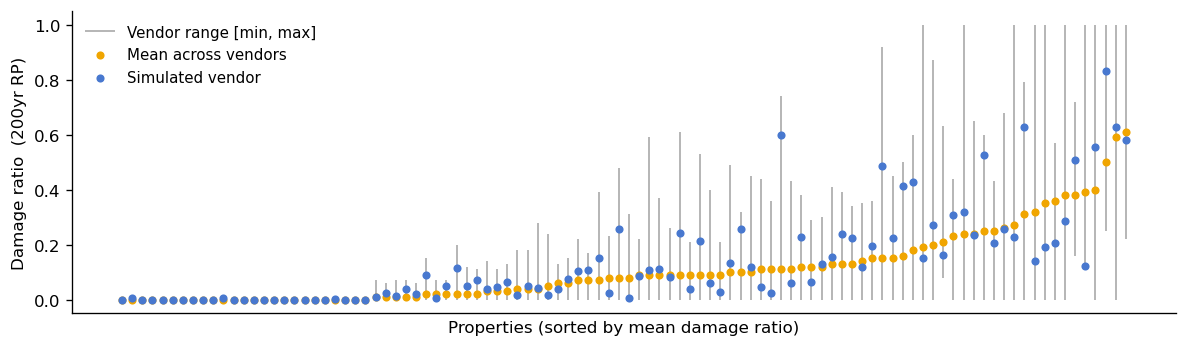

In [15]:
# Vendor spread by property (sorted by mean damage ratio)
fig, ax = plt.subplots(figsize=(10, 3))
ax.vlines(x_pos, tri_a[idx], tri_b[idx], color=GREY, linewidth=1.2, alpha=0.6,
          label='Vendor range [min, max]')
ax.scatter(x_pos, df['mean_dr'].values[idx], color=AMBER, s=15, zorder=3,
           label='Mean across vendors')
ax.scatter(x_pos, d_vendor[idx], color=BLUE, s=15, zorder=3, label='Simulated vendor')
ax.set_xlabel('Properties (sorted by mean damage ratio)')
ax.set_ylabel('Damage ratio  (200yr RP)')
ax.set_xticks([])
ax.legend(frameon=False, fontsize=9, loc='upper left')
plt.tight_layout()
plt.show()

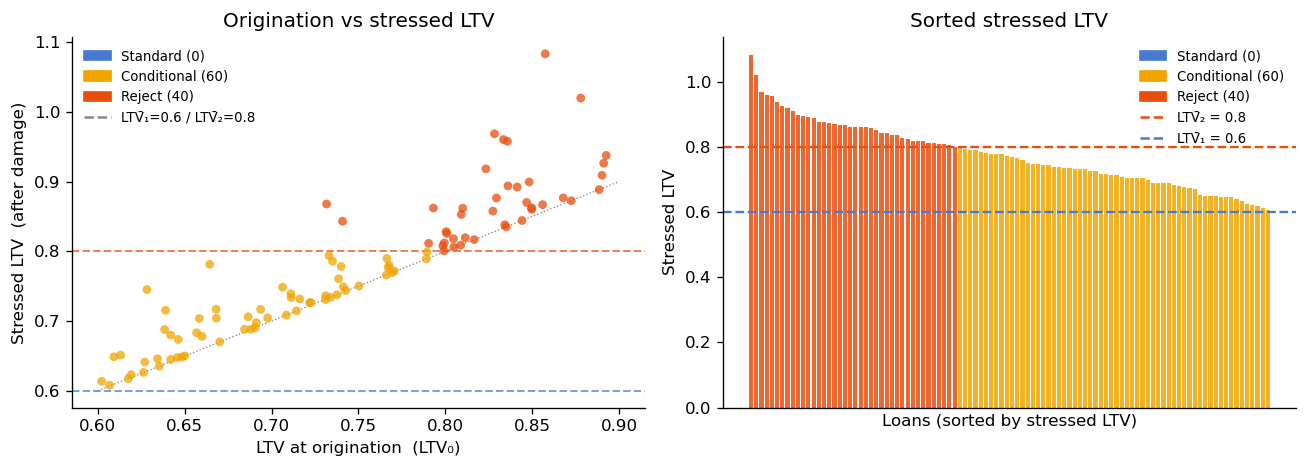

In [16]:
# Stressed LTV scatter and outcome breakdown
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# ── Left: LTV_0 vs LTV_stressed, coloured by outcome ────────────────────────
ax = axes[0]
colours_loan = [BLUE if o == 0 else (AMBER if o == 1 else RED) for o in outcome]
ax.scatter(ltv_0, ltv_stressed, c=colours_loan, s=28, alpha=0.75, edgecolors='none', zorder=3)
ax.axhline(LTV_BAR_1, color=BLUE,  lw=1.2, ls='--', alpha=0.7,
           label=f'LTV̄₁ = {LTV_BAR_1}  (standard/conditional)')
ax.axhline(LTV_BAR_2, color=RED,   lw=1.2, ls='--', alpha=0.7,
           label=f'LTV̄₂ = {LTV_BAR_2}  (conditional/reject)')
ax.plot([LTV0_LOW, LTV0_HIGH], [LTV0_LOW, LTV0_HIGH], color=GREY, lw=0.8, ls=':',
        label='No damage (LTV_s = LTV_0)')
n0, n1, n2 = [(outcome == k).sum() for k in range(3)]
ax.legend(handles=[
    mpatches.Patch(color=BLUE,  label=f'Standard ({n0})'),
    mpatches.Patch(color=AMBER, label=f'Conditional ({n1})'),
    mpatches.Patch(color=RED,   label=f'Reject ({n2})'),
    plt.Line2D([0],[0], color=GREY, ls='--', label=f'LTV̄₁={LTV_BAR_1} / LTV̄₂={LTV_BAR_2}'),
], frameon=False, fontsize=8)
ax.set_xlabel('LTV at origination  (LTV₀)')
ax.set_ylabel('Stressed LTV  (after damage)')
ax.set_title('Origination vs stressed LTV')

# ── Right: sorted stressed LTV bars coloured by outcome ─────────────────────
ax = axes[1]
order = np.argsort(ltv_stressed)[::-1]
bar_colours = [BLUE if outcome[o]==0 else (AMBER if outcome[o]==1 else RED) for o in order]
ax.bar(np.arange(n), ltv_stressed[order], color=bar_colours, width=0.8, alpha=0.85)
ax.axhline(LTV_BAR_2, color=RED,  lw=1.4, ls='--')
ax.axhline(LTV_BAR_1, color=BLUE, lw=1.4, ls='--')
ax.set_xlabel('Loans (sorted by stressed LTV)')
ax.set_ylabel('Stressed LTV')
ax.set_xticks([])
ax.legend(handles=[
    mpatches.Patch(color=BLUE,  label=f'Standard ({n0})'),
    mpatches.Patch(color=AMBER, label=f'Conditional ({n1})'),
    mpatches.Patch(color=RED,   label=f'Reject ({n2})'),
    plt.Line2D([0],[0], color=RED,  ls='--', label=f'LTV̄₂ = {LTV_BAR_2}'),
    plt.Line2D([0],[0], color=BLUE, ls='--', label=f'LTV̄₁ = {LTV_BAR_1}'),
], frameon=False, fontsize=8)
ax.set_title('Sorted stressed LTV')

plt.tight_layout()
plt.show()

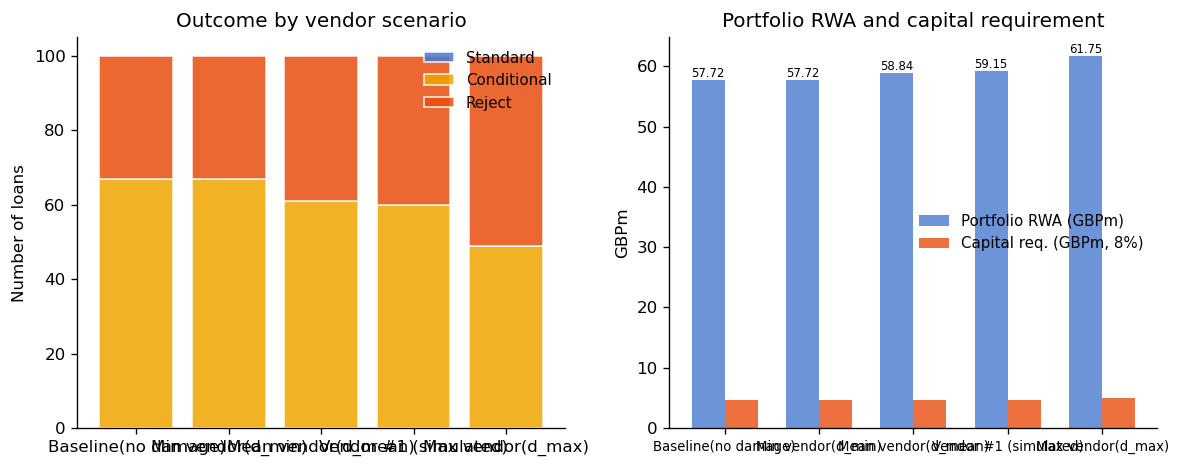

Portfolio RWA:
  Baseline(no damage)            GBP57.724m  (+0.0% vs baseline)
  Min vendor(d_min)              GBP57.724m  (+0.0% vs baseline)
  Mean vendor(d_mean)            GBP58.835m  (+1.9% vs baseline)
  Vendor #1 (simulated)          GBP59.153m  (+2.5% vs baseline)
  Max vendor(d_max)              GBP61.752m  (+7.0% vs baseline)


In [17]:
# Outcome distribution and RWA across vendor scenarios
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

scenarios    = ['Baseline(no damage)', 'Min vendor(d_min)', 'Mean vendor(d_mean)', f'Vendor #{VENDOR_SEED} (simulated)', 'Max vendor(d_max)']
all_outcomes = [outcome_base, out_min, out_mean, outcome, out_max]
all_rwa      = [rwa_base, rwa_min, rwa_mean, rwa, rwa_max]

# ── Left: stacked bar — outcome counts ───────────────────────────────────────
ax = axes[0]
bottom = np.zeros(len(scenarios))
for k, (name, col) in enumerate(zip(out_names, [BLUE, AMBER, RED])):
    vals = np.array([(o == k).sum() for o in all_outcomes], dtype=float)
    ax.bar(scenarios, vals, bottom=bottom, label=name, color=col, edgecolor='white', alpha=0.85)
    bottom += vals
ax.set_ylabel('Number of loans')
ax.set_title('Outcome by vendor scenario')
ax.legend(frameon=False, fontsize=9)

# ── Right: portfolio RWA and capital ─────────────────────────────────────────
ax = axes[1]
port_rwas    = [r.sum() for r in all_rwa]
port_capital = [CAPITAL_RATIO * r for r in port_rwas]
x = np.arange(len(scenarios))
w = 0.35
bars_rwa = ax.bar(x - w/2, port_rwas,    width=w, color=BLUE, alpha=0.8,
                  label='Portfolio RWA (GBPm)')
bars_cap = ax.bar(x + w/2, port_capital, width=w, color=RED,  alpha=0.8,
                  label=f'Capital req. (GBPm, {CAPITAL_RATIO*100:.0f}%)')
ax.set_xticks(x)
ax.set_xticklabels(scenarios, fontsize=8)
ax.set_ylabel('GBPm')
ax.set_title('Portfolio RWA and capital requirement')
ax.legend(frameon=False, fontsize=9)
for bar in bars_rwa:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=7)

plt.tight_layout()
plt.show()

print(f"Portfolio RWA:")
for sc, r in zip(scenarios, port_rwas):
    label = sc.replace('\n', ' ')
    print(f"  {label:30s} GBP{r:.3f}m  ({(r/port_rwas[0]-1)*100:+.1f}% vs baseline)")

---
## THETA Comparison: Side-by-side figures across two damage pass-through values

Edit `THETA_A`, `THETA_B`, and `FRAMING_COMPARE` in the next cell, then run all cells in this section.

**What this shows**: how sensitive the Basel III risk-weight outcome is to the assumed damage
pass-through parameter.  A bank that assumes full pass-through (θ=1) will see very different
capital requirements from one that assumes partial pass-through (θ=0.5), and will also be
more exposed to vendor disagreement flipping loans across LTV thresholds.

In [18]:
# =============================================================================
# THETA COMPARISON -- parameters
# Edit these variables; everything below recomputes automatically.
# =============================================================================

THETA_A          = 1.0    # full pass-through (baseline)
THETA_B          = 0.50   # partial pass-through (e.g. flood resilience / insurance)
FRAMING_COMPARE  = 'conditional'  # 'conditional'  or  'aal'
N_DRAWS_COMPARE  = 100    # vendor draws for uncertainty sweep

In [19]:
# =============================================================================
# THETA COMPARISON -- computation
# Runs the full simulation for THETA_A and THETA_B.
# Depends on: data / portfolio variables from cell 2; LTV thresholds from cell 1.
# =============================================================================

def _run_theta_sim(theta, framing, n_draws):
    """Return all arrays needed for the comparison figures."""
    # Single vendor draw (for LTV bar and RWA bar charts)
    d_v = triangular_sample(np.random.default_rng(VENDOR_SEED), tri_a, tri_b, tri_c)
    d1  = d_v if framing == 'conditional' else d_v * AAL_FACTOR

    v_imp1 = np.maximum(v0 * (1.0 - theta * d1), v0 * 1e-6)
    ltv1   = loan / v_imp1
    out1   = np.where(ltv1 <= LTV_BAR_1, 0, np.where(ltv1 <= LTV_BAR_2, 1, 2))
    rw1    = np.array([RW_STANDARD, RW_CONDITIONAL, RW_REJECT])[out1]
    rwa1   = loan * rw1
    cap1   = CAPITAL_RATIO * rwa1

    # N vendor draws (uncertainty sweep)
    _rng  = np.random.default_rng(0)
    d_mat = np.stack([triangular_sample(_rng, tri_a, tri_b, tri_c) for _ in range(n_draws)])
    d_eff = d_mat if framing == 'conditional' else d_mat * AAL_FACTOR

    v_imp_m = np.maximum(v0[None, :] * (1.0 - theta * d_eff), v0[None, :] * 1e-6)
    ltv_m   = loan[None, :] / v_imp_m
    out_m   = np.where(ltv_m <= LTV_BAR_1, 0, np.where(ltv_m <= LTV_BAR_2, 1, 2))
    rw_m    = np.array([RW_STANDARD, RW_CONDITIONAL, RW_REJECT])[out_m]
    rwa_m   = loan[None, :] * rw_m
    cap_m   = CAPITAL_RATIO * rwa_m
    port_rwa = rwa_m.sum(axis=1)     # (n_draws,)
    port_cap = cap_m.sum(axis=1)     # (n_draws,)

    # Staging stability: does outcome vary across vendor draws per loan?
    out_max_per_loan = out_m.max(axis=0)
    out_min_per_loan = out_m.min(axis=0)
    always_std  = out_max_per_loan == 0
    always_rej  = out_min_per_loan == 2
    unstable    = out_max_per_loan != out_min_per_loan

    # Pairwise portfolio RWA disagreement
    ii, jj   = np.triu_indices(n_draws, k=1)
    rwa_diff = np.abs(port_rwa[ii] - port_rwa[jj])

    return dict(
        theta=theta, framing=framing,
        ltv_single=ltv1, outcome_single=out1, rwa_single=rwa1, cap_single=cap1,
        port_rwa=port_rwa, port_cap=port_cap,
        unstable=unstable, always_std=always_std, always_rej=always_rej,
        rwa_diff=rwa_diff,
    )


_fl = ('Conditional (p=1)' if FRAMING_COMPARE == 'conditional'
       else f'AAL (d×{AAL_FACTOR})')

sim_a = _run_theta_sim(THETA_A, FRAMING_COMPARE, N_DRAWS_COMPARE)
sim_b = _run_theta_sim(THETA_B, FRAMING_COMPARE, N_DRAWS_COMPARE)

for s in (sim_a, sim_b):
    n0, n1, n2 = [(s['outcome_single'] == k).sum() for k in range(3)]
    print(f"theta={s['theta']}  |  Standard:{n0:2d}  Conditional:{n1:2d}  Reject:{n2:2d}  "
          f"|  Mean portfolio RWA: GBP{s['port_rwa'].mean():.3f}m  |  {_fl}")

theta=1.0  |  Standard: 0  Conditional:39  Reject:61  |  Mean portfolio RWA: GBP62.738m  |  Conditional (p=1)
theta=0.5  |  Standard: 0  Conditional:52  Reject:48  |  Mean portfolio RWA: GBP60.762m  |  Conditional (p=1)


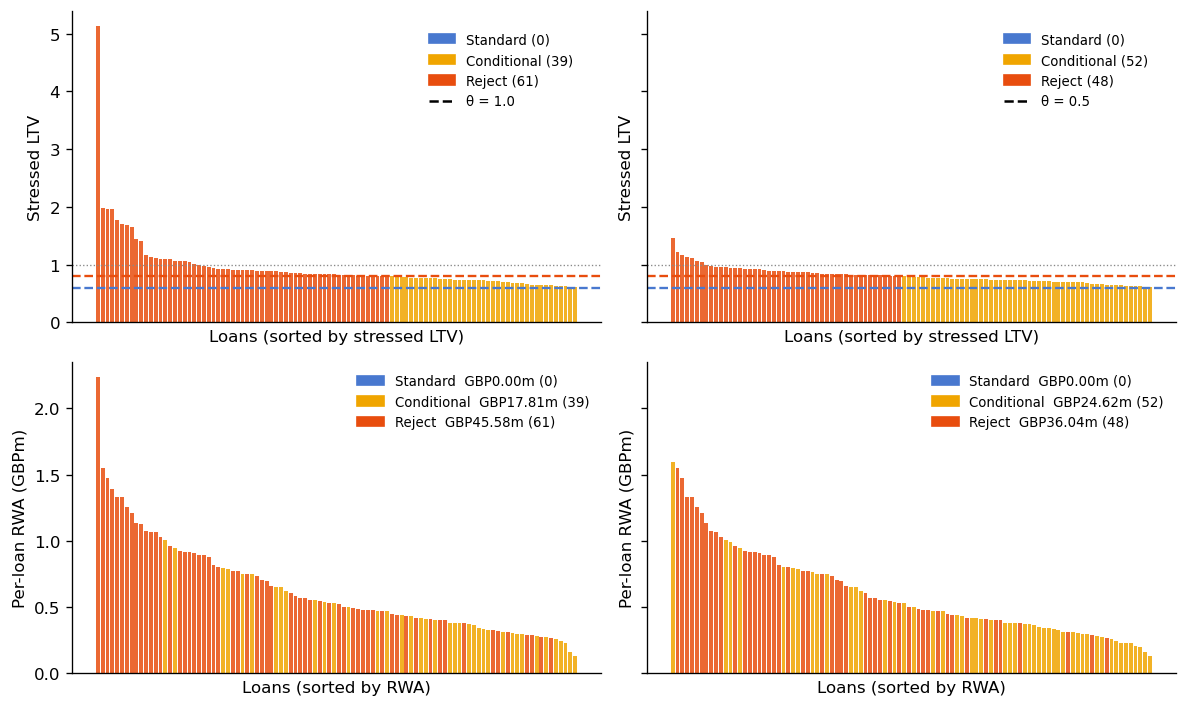

In [20]:
# Figure 1 -- 2x2: stressed LTV (top row) and per-loan RWA (bottom row), theta_A vs theta_B
fig, axes = plt.subplots(2, 2, figsize=(10, 6), sharey='row')

# ── Top row: sorted stressed LTV ─────────────────────────────────────────────
for ax, s in zip(axes[0], (sim_a, sim_b)):
    ltv_s  = s['ltv_single']
    out    = s['outcome_single']
    order  = np.argsort(ltv_s)[::-1]
    n0, n1, n2 = [(out == k).sum() for k in range(3)]
    cols   = [BLUE if out[o]==0 else (AMBER if out[o]==1 else RED) for o in order]
    ax.bar(np.arange(n), ltv_s[order], color=cols, width=0.8, alpha=0.85)
    ax.axhline(LTV_BAR_2, color=RED,  lw=1.4, ls='--')
    ax.axhline(LTV_BAR_1, color=BLUE, lw=1.4, ls='--')
    ax.axhline(1.0,        color=GREY, lw=0.8, ls=':')
    ax.set_xlabel('Loans (sorted by stressed LTV)')
    ax.set_ylabel('Stressed LTV')
    ax.set_xticks([])
    ax.legend(handles=[
        mpatches.Patch(color=BLUE,  label=f'Standard ({n0})'),
        mpatches.Patch(color=AMBER, label=f'Conditional ({n1})'),
        mpatches.Patch(color=RED,   label=f'Reject ({n2})'),
        plt.Line2D([0],[0], color='black', ls='--',
                   label=f'\u03b8 = {s["theta"]}'),
    ], loc='upper right', bbox_to_anchor=(0.97, 0.97), frameon=False, fontsize=8)

# ── Bottom row: per-loan RWA ─────────────────────────────────────────────────
for ax, s in zip(axes[1], (sim_a, sim_b)):
    out    = s['outcome_single']
    rwa_s  = s['rwa_single']
    order  = np.argsort(rwa_s)[::-1]
    n0, n1, n2 = [(out == k).sum() for k in range(3)]
    rwa_n0 = rwa_s[out == 0].sum()
    rwa_n1 = rwa_s[out == 1].sum()
    rwa_n2 = rwa_s[out == 2].sum()
    cols   = [BLUE if out[o]==0 else (AMBER if out[o]==1 else RED) for o in order]
    ax.bar(np.arange(n), rwa_s[order], color=cols, width=0.8, alpha=0.85)
    ax.set_xlabel('Loans (sorted by RWA)')
    ax.set_ylabel('Per-loan RWA (GBPm)')
    ax.set_xticks([])
    ax.legend(handles=[
        mpatches.Patch(color=BLUE,  label=f'Standard  GBP{rwa_n0:.2f}m ({n0})'),
        mpatches.Patch(color=AMBER, label=f'Conditional  GBP{rwa_n1:.2f}m ({n1})'),
        mpatches.Patch(color=RED,   label=f'Reject  GBP{rwa_n2:.2f}m ({n2})'),
    ], frameon=False, fontsize=8)

plt.tight_layout()
plt.show()

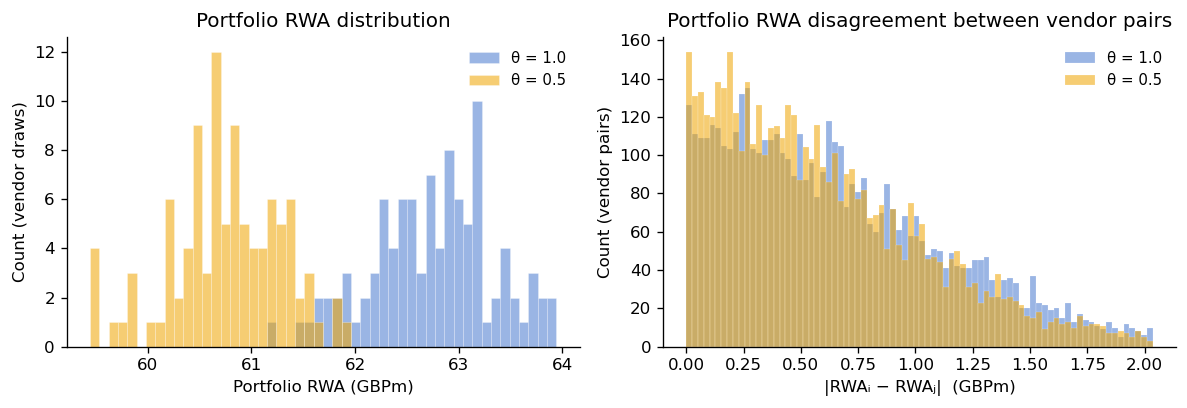

In [21]:
# Figure 2 -- overlaid histograms: portfolio RWA distribution (left) and pairwise disagreement (right)
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))

# ── Left: portfolio RWA distribution ─────────────────────────────────────────
ax = axes[0]
all_rwa_vals = np.concatenate([sim_a['port_rwa'], sim_b['port_rwa']])
bins_rwa = np.linspace(all_rwa_vals.min(), all_rwa_vals.max(), 51)
for s, col in ((sim_a, BLUE), (sim_b, AMBER)):
    ax.hist(s['port_rwa'], bins=bins_rwa, color=col, alpha=0.55,
            edgecolor='white', linewidth=0.3, label=f'\u03b8 = {s["theta"]}')
ax.set_xlabel('Portfolio RWA (GBPm)')
ax.set_ylabel('Count (vendor draws)')
ax.set_title('Portfolio RWA distribution')
ax.legend(frameon=False, fontsize=9)

# ── Right: pairwise |ΔRWA| between vendor pairs ───────────────────────────────
ax = axes[1]
all_diff = np.concatenate([sim_a['rwa_diff'], sim_b['rwa_diff']])
bins_diff = np.linspace(0, np.percentile(all_diff, 99), 81)
for s, col in ((sim_a, BLUE), (sim_b, AMBER)):
    ax.hist(s['rwa_diff'], bins=bins_diff, color=col, alpha=0.55,
            edgecolor='white', linewidth=0.2, label=f'\u03b8 = {s["theta"]}')
ax.set_xlabel('|RWAᵢ − RWAⱼ|  (GBPm)')
ax.set_ylabel('Count (vendor pairs)')
ax.set_title('Portfolio RWA disagreement between vendor pairs')
ax.legend(frameon=False, fontsize=9)

plt.tight_layout()
plt.show()

In [12]:
# =============================================================================
# SUMMARY STATISTICS
# =============================================================================

ead_total = loan.sum()

def _stats(s):
    port   = s['port_rwa']
    cap    = s['port_cap']
    diff   = s['rwa_diff']
    out    = s['outcome_single']
    rwa_s  = s['rwa_single']
    unstable  = s['unstable']
    always_s  = s['always_std']
    always_r  = s['always_rej']
    return {
        # ── single vendor draw ──────────────────────────────────────────────
        'Standard loans':                           int((out == 0).sum()),
        'Conditional loans':                        int((out == 1).sum()),
        'Reject loans':                             int((out == 2).sum()),
        'Portfolio RWA — single draw (GBPm)':       round(rwa_s.sum(), 3),
        'Capital req. — single draw (GBPm)':        round(CAPITAL_RATIO * rwa_s.sum(), 4),
        'RWA density (% of loan book)':             round(rwa_s.sum() / ead_total * 100, 2),
        # ── vendor uncertainty (N draws) ────────────────────────────────────
        'RWA mean across vendors (GBPm)':           round(port.mean(), 3),
        'RWA std across vendors (GBPm)':            round(port.std(), 4),
        'RWA CV across vendors':                    round(port.std() / port.mean(), 4),
        'RWA P10 (GBPm)':                           round(float(np.percentile(port, 10)), 3),
        'RWA P50 / median (GBPm)':                  round(float(np.percentile(port, 50)), 3),
        'RWA P90 (GBPm)':                           round(float(np.percentile(port, 90)), 3),
        'RWA range P90/P10':                        round(float(np.percentile(port, 90) / np.percentile(port, 10)), 4),
        'RWA range / mean':                         round((port.max() - port.min()) / port.mean(), 4),
        # ── outcome stability ───────────────────────────────────────────────
        'Always Standard across vendors (n)':       int(always_s.sum()),
        'Outcome unstable — flip bucket (n)':       int(unstable.sum()),
        'Always Reject across vendors (n)':         int(always_r.sum()),
        'Bucket instability rate':                  round(float(unstable.mean()), 4),
        # ── pairwise vendor comparison ──────────────────────────────────────
        'Pairwise |\u0394RWA| median (GBPm)':          round(float(np.median(diff)), 4),
        'Pairwise |\u0394RWA| P90 (GBPm)':             round(float(np.percentile(diff, 90)), 4),
        'Pairwise |\u0394RWA| median (% mean RWA)':    round(float(np.median(diff)) / port.mean() * 100, 2),
    }

col_a = f'\u03b8 = {THETA_A}'
col_b = f'\u03b8 = {THETA_B}'
df_stats = pd.DataFrame({col_a: _stats(sim_a), col_b: _stats(sim_b)})
df_stats['Diff (B \u2212 A)'] = (pd.to_numeric(df_stats[col_b], errors='coerce')
                                  - pd.to_numeric(df_stats[col_a], errors='coerce'))

sections = [
    ('Single vendor draw', [
        'Standard loans', 'Conditional loans', 'Reject loans',
        'Portfolio RWA — single draw (GBPm)', 'Capital req. — single draw (GBPm)',
        'RWA density (% of loan book)',
    ]),
    ('Vendor uncertainty (N draws)', [
        'RWA mean across vendors (GBPm)', 'RWA std across vendors (GBPm)',
        'RWA CV across vendors',
        'RWA P10 (GBPm)', 'RWA P50 / median (GBPm)', 'RWA P90 (GBPm)',
        'RWA range P90/P10', 'RWA range / mean',
    ]),
    ('Outcome stability', [
        'Always Standard across vendors (n)', 'Outcome unstable — flip bucket (n)',
        'Always Reject across vendors (n)', 'Bucket instability rate',
    ]),
    ('Pairwise vendor comparison', [
        'Pairwise |\u0394RWA| median (GBPm)',
        'Pairwise |\u0394RWA| P90 (GBPm)',
        'Pairwise |\u0394RWA| median (% mean RWA)',
    ]),
]

print(f'Framing: {_fl}  |  N vendor draws = {N_DRAWS_COMPARE}')
print(f'Total loan book (EAD): GBP{ead_total:.2f}m\n')

for section_name, keys in sections:
    print(f'\n--- {section_name} ---')
    display(df_stats.loc[keys].style
            .format(lambda v: f'{v:.4g}' if isinstance(v, float) else (str(v) if pd.notna(v) else ''),
                    subset=[col_a, col_b])
            .format(lambda v: f'{v:+.4g}' if pd.notna(v) else '', subset=['Diff (B \u2212 A)'])
            .set_caption(section_name)
            .set_table_styles([{'selector': 'caption',
                                'props': [('font-weight', 'bold'), ('font-size', '1em')]}]))

Framing: Conditional (p=1)  |  N vendor draws = 100
Total loan book (EAD): GBP67.15m


--- Single vendor draw ---


,θ = 1.0,θ = 0.5,Diff (B − A)
Standard loans,0,0,+0
Conditional loans,39,52,+13
Reject loans,61,48,-13
Portfolio RWA — single draw (GBPm),63.38,60.66,-2.726
Capital req. — single draw (GBPm),5.071,4.853,-0.218
RWA density (% of loan book),94.39,90.33,-4.06



--- Vendor uncertainty (N draws) ---


,θ = 1.0,θ = 0.5,Diff (B − A)
RWA mean across vendors (GBPm),62.74,60.76,-1.976
RWA std across vendors (GBPm),0.5913,0.5387,-0.0526
RWA CV across vendors,0.0094,0.0089,-0.0005
RWA P10 (GBPm),61.89,60.12,-1.767
RWA P50 / median (GBPm),62.78,60.76,-2.02
RWA P90 (GBPm),63.47,61.41,-2.062
RWA range P90/P10,1.026,1.021,-0.0041
RWA range / mean,0.0437,0.0414,-0.0023



--- Outcome stability ---


,θ = 1.0,θ = 0.5,Diff (B − A)
Always Standard across vendors (n),0,0,+0
Outcome unstable — flip bucket (n),38,32,-6
Always Reject across vendors (n),35,34,-1
Bucket instability rate,0.38,0.32,-0.06



--- Pairwise vendor comparison ---


,θ = 1.0,θ = 0.5,Diff (B − A)
Pairwise |ΔRWA| median (GBPm),0.5874,0.5138,-0.0736
Pairwise |ΔRWA| P90 (GBPm),1.39,1.259,-0.1309
Pairwise |ΔRWA| median (% mean RWA),0.94,0.85,-0.09
